In [1]:
%pylab inline
import scanpy as sc
import pandas as pd
import seaborn as sns
import numpy as np
import scanpy as sc
import seaborn as sns
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
rcParams['pdf.fonttype']=42 # in order to save fonttype in AI
rcParams['ps.fonttype']=42

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## Integrate the Micros……

In [2]:
# load monkey AIC Oligo data of our current project.
insData = sc.read('../data_h5/Insular_sorted_clusters.h5ad')

In [3]:
insData

AnnData object with n_obs × n_vars = 122663 × 19944
    obs: 'batch', 'doublet_score', 'predicted_doublets', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Sex', 'Sample', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'cellTypeID_2', 'cellType_labels_2', 'sampleLayers'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Sample_colors', 'Sex_colors', 'batch_colors', 'cellTypeID_2_colors', 'cellTypeID_colors', 'cellTypeLabel_colors', 'cellType_labels_2_colors', 'cell_subtypeID_colors', 'cell_subtypeLabels_colors', 'dendrogram_cellTypeLabel', 'dendrogram_cellType_labels_2', 'dendrogram_cell_subtypeLabels', 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sampleLayers_colors', 'tsne', 'umap'
    obsm: 'X_harmonypca', 'X_pca', 'X_tsne', 'X_umap', 'X_umapharmony', '

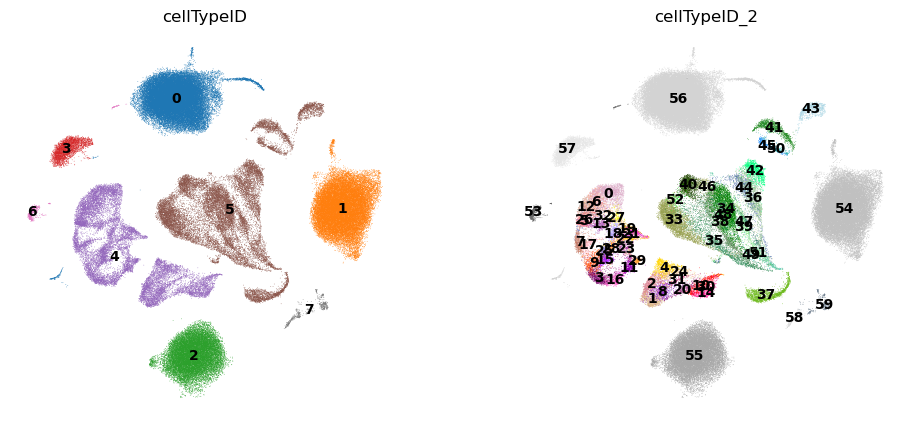

In [4]:
figsize(5,5)
sc.pl.umap(insData,color=['cellTypeID','cellTypeID_2'],legend_loc='on data',frameon=False)

In [5]:
adata_Glias = insData[insData.obs['cellTypeID'].isin(['0','1','2','3']),]
adata_Glias

View of AnnData object with n_obs × n_vars = 83283 × 19944
    obs: 'batch', 'doublet_score', 'predicted_doublets', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Sex', 'Sample', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'cellTypeID_2', 'cellType_labels_2', 'sampleLayers'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Sample_colors', 'Sex_colors', 'batch_colors', 'cellTypeID_2_colors', 'cellTypeID_colors', 'cellTypeLabel_colors', 'cellType_labels_2_colors', 'cell_subtypeID_colors', 'cell_subtypeLabels_colors', 'dendrogram_cellTypeLabel', 'dendrogram_cellType_labels_2', 'dendrogram_cell_subtypeLabels', 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sampleLayers_colors', 'tsne', 'umap'
    obsm: 'X_harmonypca', 'X_pca', 'X_tsne', 'X_umap', 'X_umapharm

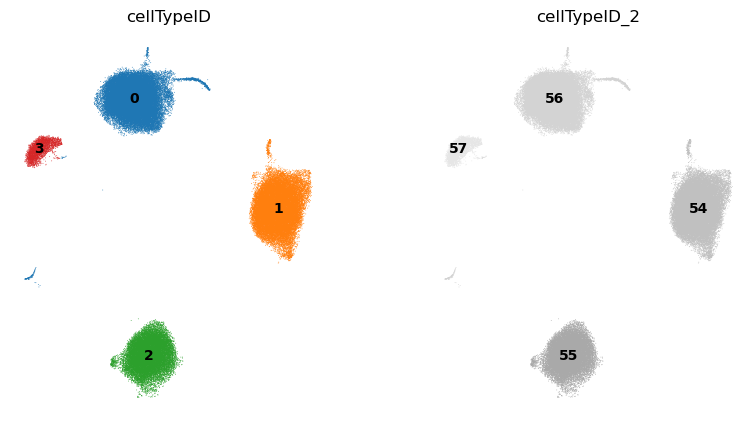

In [6]:
figsize(4,5)
sc.pl.umap(adata_Glias,color=['cellTypeID','cellTypeID_2'],legend_loc='on data',frameon=False)

In [7]:
ins_glia=sc.AnnData(adata_Glias.layers['counts'],dict(obs_names=adata_Glias.obs_names),dict(var_names=adata_Glias.var_names))
ins_glia.obs['batch'] = adata_Glias.obs['batch'].astype('str')
ins_glia.obs['area'] = 'Ins'
ins_glia.obs['species'] = 'mk'
ins_glia.obs['cellTypeID'] = adata_Glias.obs['cellTypeID']
ins_glia.obs['cellTypeLabel'] = adata_Glias.obs['cellTypeLabel']
ins_glia.obs['Sex'] = adata_Glias.obs['Sex']
ins_glia.obs['Sample'] = adata_Glias.obs['Sample']
ins_glia.obs['cellTypeID_2'] = adata_Glias.obs['cellTypeID_2']
ins_glia.obs['cellType_labels_2'] = adata_Glias.obs['cellType_labels_2']

In [8]:
ins_glia

AnnData object with n_obs × n_vars = 83283 × 19944
    obs: 'batch', 'area', 'species', 'cellTypeID', 'cellTypeLabel', 'Sex', 'Sample', 'cellTypeID_2', 'cellType_labels_2'

In [9]:
sc.pp.subsample(ins_glia, 0.05)
ins_glia

AnnData object with n_obs × n_vars = 4164 × 19944
    obs: 'batch', 'area', 'species', 'cellTypeID', 'cellTypeLabel', 'Sex', 'Sample', 'cellTypeID_2', 'cellType_labels_2'

In [10]:
# Load Siletti glia data
ad_glia_Siletti = sc.read('./data_Siletti/Siletti_mmf_nonNeuron.h5ad')
ad_glia_Siletti

AnnData object with n_obs × n_vars = 888263 × 59236
    obs: 'ROIGroup', 'ROIGroupCoarse', 'ROIGroupFine', 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'Biotype', 'Chromosome', 'End', 'Gene', 'Start', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X

In [11]:
ad_glia_Siletti[ ad_glia_Siletti.obs['roi'].isin(['Human FI']) ] 

View of AnnData object with n_obs × n_vars = 2338 × 59236
    obs: 'ROIGroup', 'ROIGroupCoarse', 'ROIGroupFine', 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'Biotype', 'Chromosome', 'End', 'Gene', 'Start', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    ob

In [12]:
# ad_glia_Siletti = ad_glia_Siletti[ad_glia_Siletti.obs['ROIGroup'].isin(['Cerebral cortex'])]
ad_glia_Siletti = ad_glia_Siletti[ ad_glia_Siletti.obs['roi'].isin(['Human FI']) ] 

In [13]:
ad_glia_Siletti.obsm['X_umap'] = ad_glia_Siletti.obsm['X_UMAP']
ad_glia_Siletti.obsm['X_tsne'] = ad_glia_Siletti.obsm['X_tSNE']
del(ad_glia_Siletti.obsm['X_UMAP'])
del(ad_glia_Siletti.obsm['X_tSNE'])

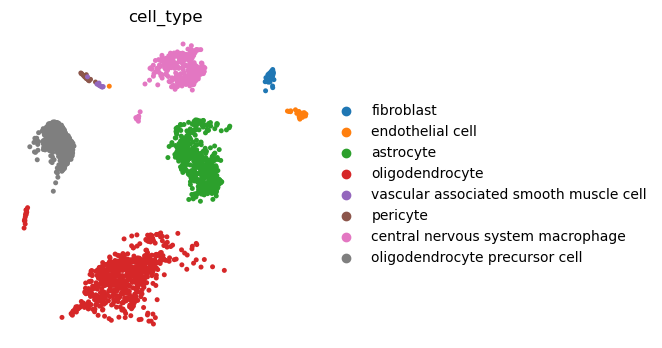

In [14]:
figsize(4,4)
sc.pl.umap(ad_glia_Siletti,color=['cell_type'],legend_loc='right margin',frameon=False)

In [15]:
ad_glia_Siletti = ad_glia_Siletti[ad_glia_Siletti.obs['cell_type'].isin(['astrocyte','central nervous system macrophage','oligodendrocyte precursor cell','oligodendrocyte']),]

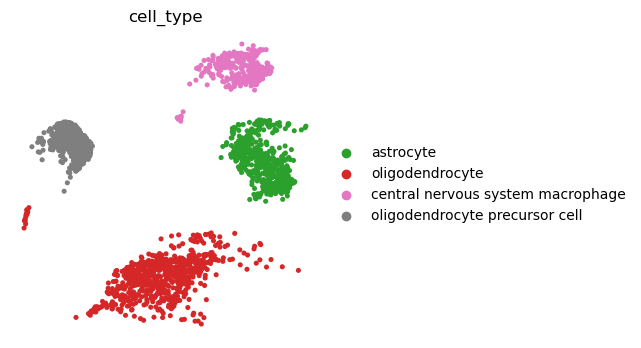

In [16]:
sc.pl.umap(ad_glia_Siletti,color=['cell_type'],legend_loc='right margin',frameon=False)

In [17]:
cell_type_id = ad_glia_Siletti.obs['cell_type'].astype('str')

cell_type_id[ ad_glia_Siletti.obs['cell_type'].isin(['astrocyte']) ] = '0'
cell_type_id[ ad_glia_Siletti.obs['cell_type'].isin(['central nervous system macrophage']) ] = '1'
cell_type_id[ ad_glia_Siletti.obs['cell_type'].isin(['oligodendrocyte precursor cell']) ] = '2'
cell_type_id[ ad_glia_Siletti.obs['cell_type'].isin(['oligodendrocyte']) ] = '3'

ad_glia_Siletti.obs['cell_type_id'] = cell_type_id.astype('category')

In [18]:
ad_glia_Siletti.write_h5ad('./temData/ad_glia_Siletti.h5ad')

In [19]:
# =================annotate the gene ids in the Siletti dataset =======================
# load the human gene annotation table. 
geneAnno = pd.read_csv('./geneAnnoFiles/geneID_annotation_Siletti.csv')
# remove the duplicate gene names, inluding 'NA'
geneAnno = geneAnno.drop_duplicates(subset='gene_name',keep='first')

ad_glia_Siletti = ad_glia_Siletti[:,geneAnno['gene_id']]
ad_glia_Siletti.var_names = list( geneAnno[  geneAnno['gene_id'] ==ad_glia_Siletti.var_names ]['gene_name'] )

In [20]:
ad_glia_Siletti

AnnData object with n_obs × n_vars = 2233 × 59142
    obs: 'ROIGroup', 'ROIGroupCoarse', 'ROIGroupFine', 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'cell_type_id'
    var: 'Biotype', 'Chromosome', 'End', 'Gene', 'Start', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title

In [21]:
glia_siletti=sc.AnnData(ad_glia_Siletti.X,dict(obs_names=ad_glia_Siletti.obs_names),dict(var_names=ad_glia_Siletti.var_names))
glia_siletti.obs['roi'] = ad_glia_Siletti.obs['roi']
glia_siletti.obs['species'] = 'hu'
glia_siletti.obs['cell_type_id'] = ad_glia_Siletti.obs['cell_type_id']
glia_siletti.obs['cell_type'] = ad_glia_Siletti.obs['cell_type']
glia_siletti.obs['cluster_id'] = ad_glia_Siletti.obs['cluster_id']
glia_siletti.obs['sample_id'] = ad_glia_Siletti.obs['sample_id']
glia_siletti.obs['subcluster_id'] = ad_glia_Siletti.obs['subcluster_id']
glia_siletti.obs['tissue'] = ad_glia_Siletti.obs['tissue']
glia_siletti.obs['sex'] = ad_glia_Siletti.obs['sex']

In [22]:
adata = ins_glia.concatenate(glia_siletti,index_unique=None)

In [23]:
adata.write_h5ad('./temData/merged_raw_AllGlia_siletti_step1.h5ad')

In [24]:
adata

AnnData object with n_obs × n_vars = 6397 × 15189
    obs: 'batch', 'area', 'species', 'cellTypeID', 'cellTypeLabel', 'Sex', 'Sample', 'cellTypeID_2', 'cellType_labels_2', 'roi', 'cell_type_id', 'cell_type', 'cluster_id', 'sample_id', 'subcluster_id', 'tissue', 'sex'

#### Integrating……

In [25]:
adata = sc.read('./temData/merged_raw_AllGlia_siletti_step1.h5ad')

In [26]:
sc.pp.filter_cells(adata, min_genes=200)  # this does nothing, in this specific case
sc.pp.filter_genes(adata, min_cells=3)
adata

AnnData object with n_obs × n_vars = 6397 × 14157
    obs: 'batch', 'area', 'species', 'cellTypeID', 'cellTypeLabel', 'Sex', 'Sample', 'cellTypeID_2', 'cellType_labels_2', 'roi', 'cell_type_id', 'cell_type', 'cluster_id', 'sample_id', 'subcluster_id', 'tissue', 'sex', 'n_genes'
    var: 'n_cells'

In [27]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(
    adata,
    batch_key="batch",
    flavor="seurat",
    n_top_genes=500,
    subset=True,
    min_mean=0.015, 
    max_mean=10,
    min_disp=0.05
)

In [28]:
adata = adata[:, adata.var.highly_variable]
adata

View of AnnData object with n_obs × n_vars = 6397 × 500
    obs: 'batch', 'area', 'species', 'cellTypeID', 'cellTypeLabel', 'Sex', 'Sample', 'cellTypeID_2', 'cellType_labels_2', 'roi', 'cell_type_id', 'cell_type', 'cluster_id', 'sample_id', 'subcluster_id', 'tissue', 'sex', 'n_genes', 'n_genes_by_counts', 'total_counts', 'n_counts'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg'

In [29]:
sc.pp.regress_out(adata, ['total_counts'])
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

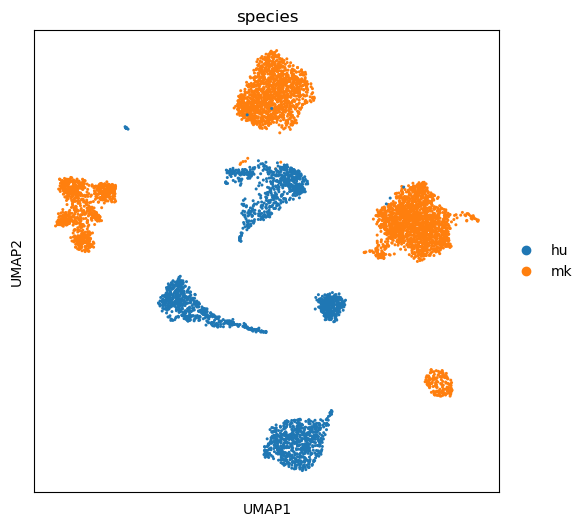

In [30]:
figsize(6,6)
sc.pl.umap(adata,color=['species'])

# Remove the batch effects and integrate the data

### Integrate data with SCVI

In [31]:
import scvi

In [32]:
adata0 = sc.read('./temData/merged_raw_AllGlia_siletti_step1.h5ad')
adata.X = adata0[:,adata.var_names].X[:]
adata.X.todense()

matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [33]:
scvi.model.SCVI.setup_anndata(
    adata,
    batch_key = 'batch',
    categorical_covariate_keys=['species'],
    continuous_covariate_keys = ['n_genes','n_counts']
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [34]:
model = scvi.model.SCVI(adata)
model.train(600)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 600/600: 100%|██████████████| 600/600 [06:01<00:00,  1.68it/s, v_num=1, train_loss_step=150, train_loss_epoch=152]

`Trainer.fit` stopped: `max_epochs=600` reached.


Epoch 600/600: 100%|██████████████| 600/600 [06:01<00:00,  1.66it/s, v_num=1, train_loss_step=150, train_loss_epoch=152]


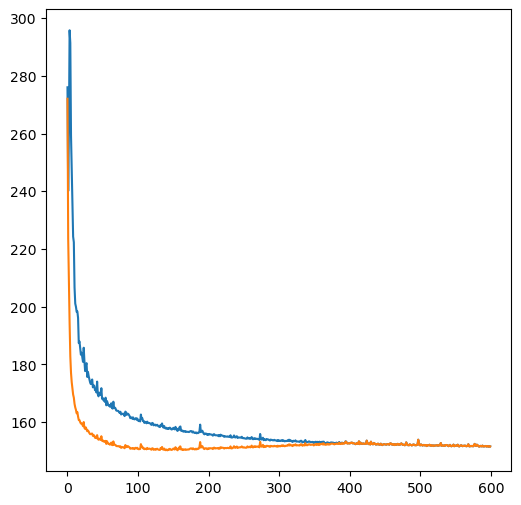

In [35]:
plt.plot(model.history['elbo_train'])
plt.plot(model.history['train_loss_epoch'])

In [36]:
adata.obsm['X_scvi'] = model.get_latent_representation()
sc.pp.neighbors(adata, use_rep="X_scvi")
sc.tl.umap(adata, min_dist=0.3)

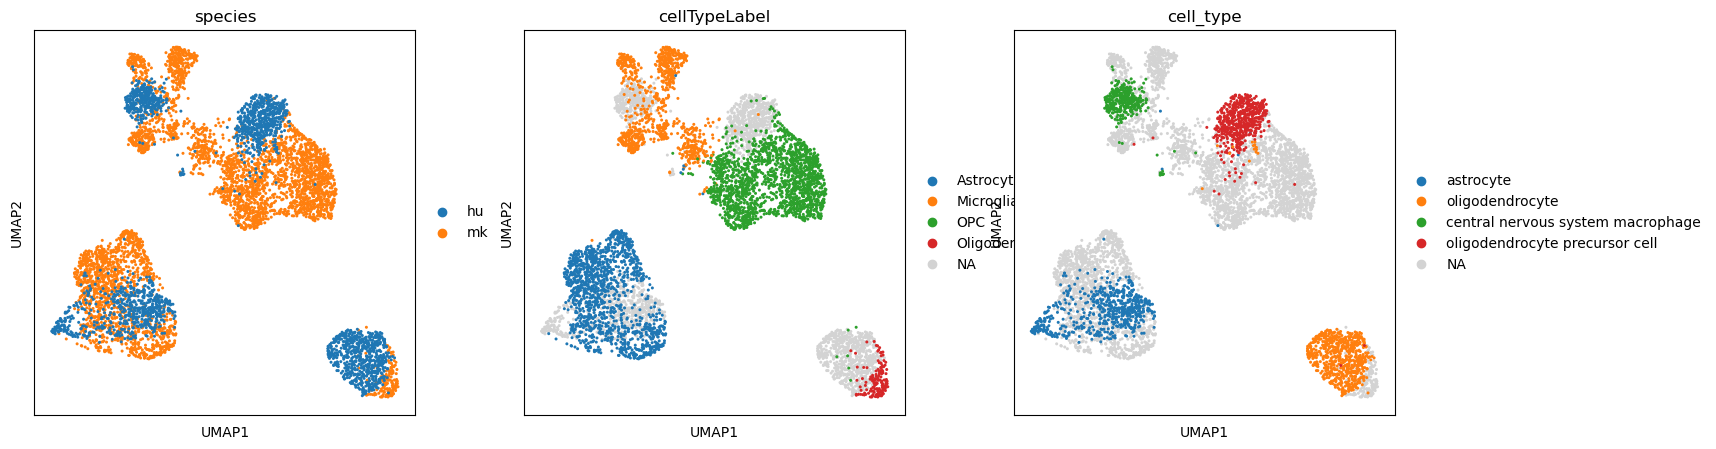

In [37]:
figsize(5,5)
sc.pl.umap(adata, color=['species','cellTypeLabel','cell_type'])

In [44]:
adata

AnnData object with n_obs × n_vars = 6397 × 500
    obs: 'batch', 'area', 'species', 'cellTypeID', 'cellTypeLabel', 'Sex', 'Sample', 'cellTypeID_2', 'cellType_labels_2', 'roi', 'cell_type_id', 'cell_type', 'cluster_id', 'sample_id', 'subcluster_id', 'tissue', 'sex', 'n_genes', 'n_genes_by_counts', 'total_counts', 'n_counts', '_scvi_batch', '_scvi_labels'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'species_colors', '_scvi_uuid', '_scvi_manager_uuid', 'cellTypeLabel_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'X_scvi'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [40]:
%pylab inline
import sys
sys.path.append('../tools')
from two_species_heatmap import *

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [41]:
ad_merged_mk_hu_integrated = adata

In [48]:
ad_merged_mk_hu_integrated.obsm['X_harmonypca'] = ad_merged_mk_hu_integrated.obsm['X_scvi']

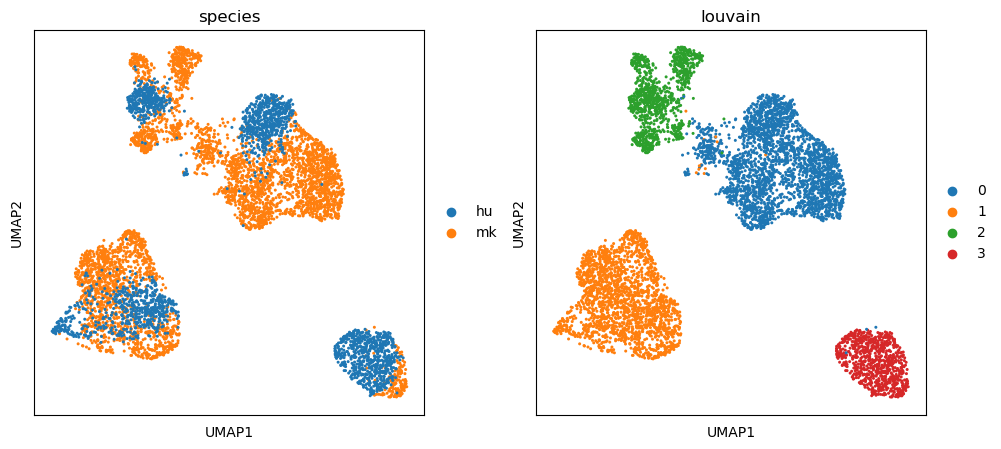

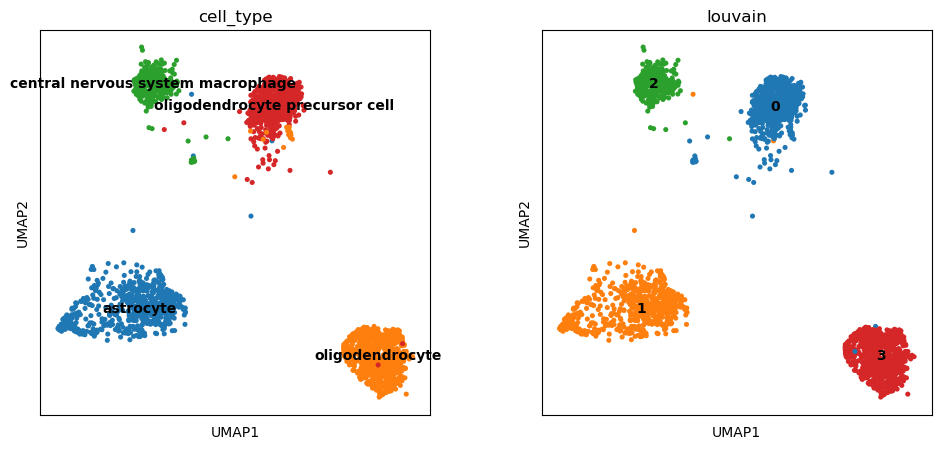

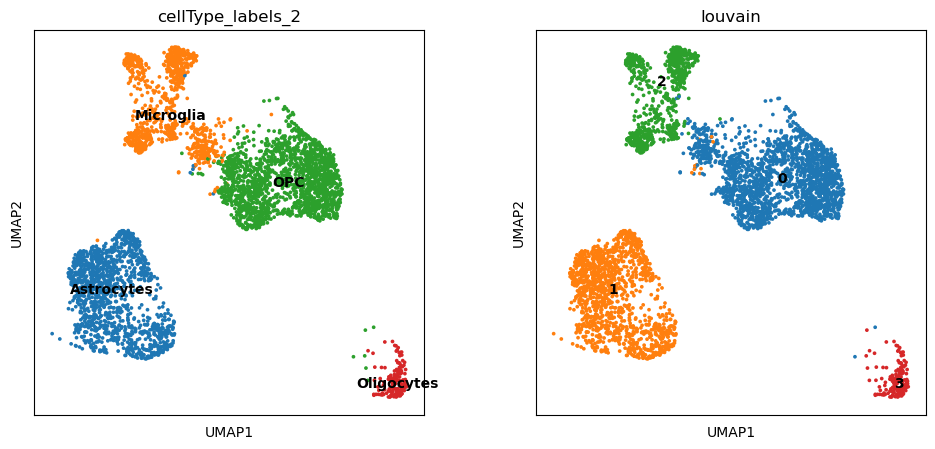

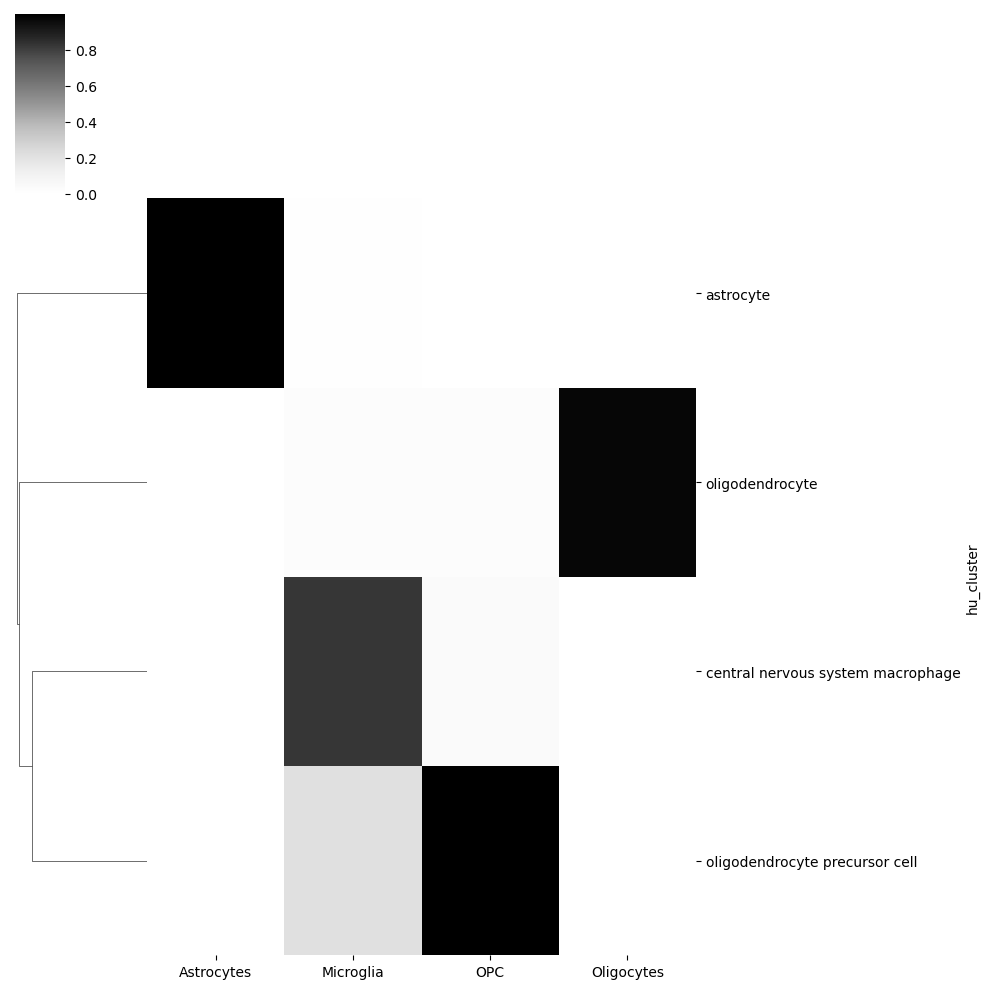

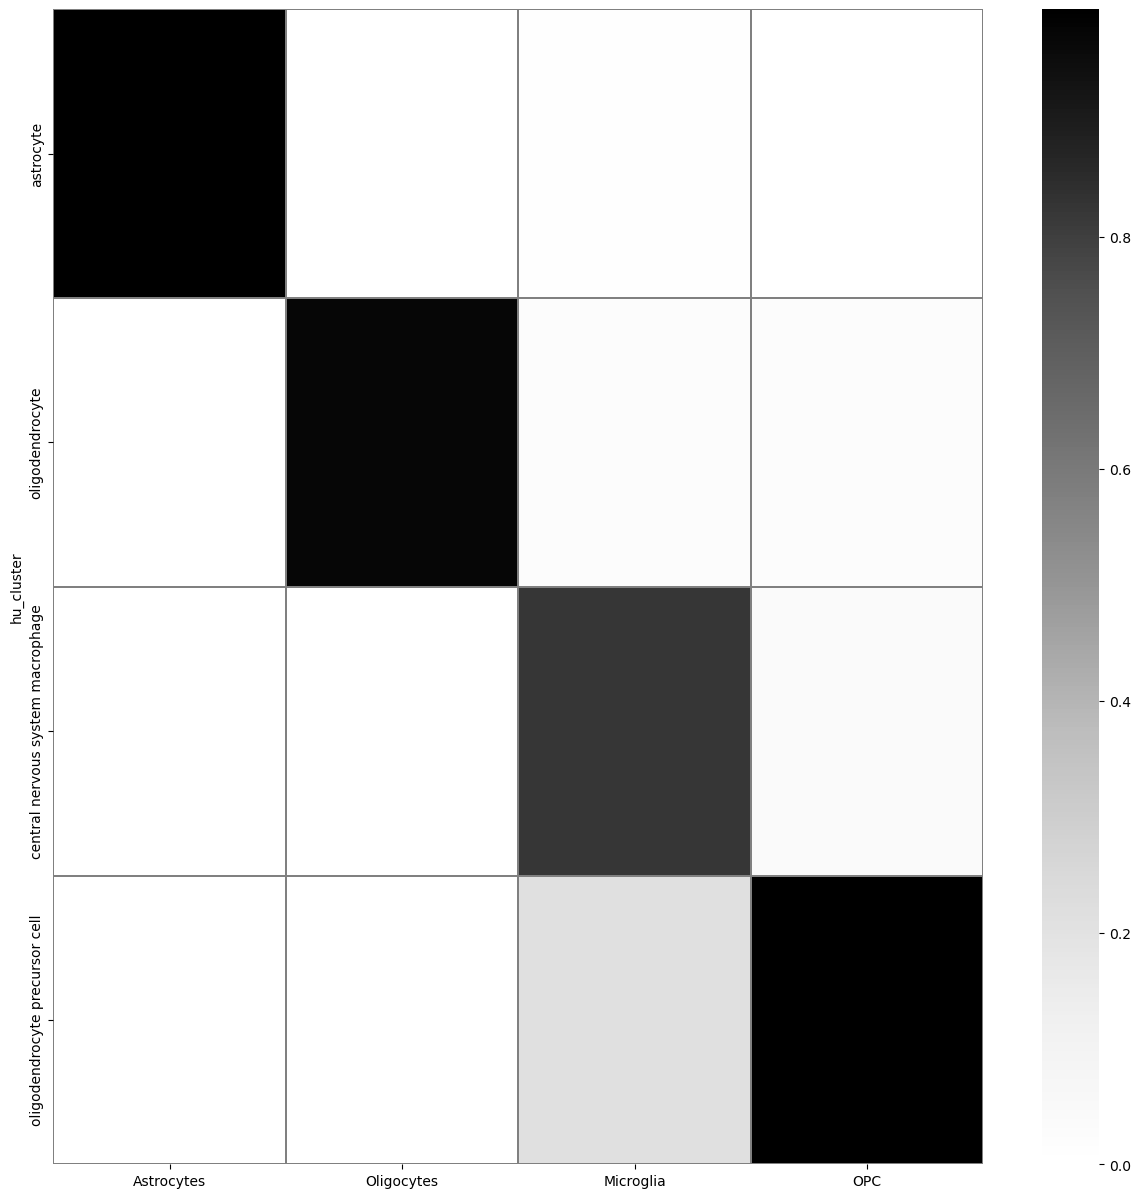

In [49]:
plot_cmpMatrix_mk_vs_hu_lovain_0_1 = two_species_heatmap(ad_merged_mk_hu_integrated, species_1 = 'hu', species_2 = 'mk',\
                species_1_key = 'cell_type', species_2_key = 'cellType_labels_2',\
                louvain = 0.05)#,figure_path = 'neurons_heatmap_cmp.png')

In [ ]:
# index_order = ['astrocyte','oligodendrocyte','central nervous system macrophage','oligodendrocyte precursor cell']
# column_order = ['Astrocytes', 'Oligocytes', 'Microglia','OPC']
# plot_cmpMatrix_mk_vs_hu_lovain_0_1=plot_cmpMatrix_mk_vs_hu_lovain_0_1.reindex(index=index_order,columns=column_order)

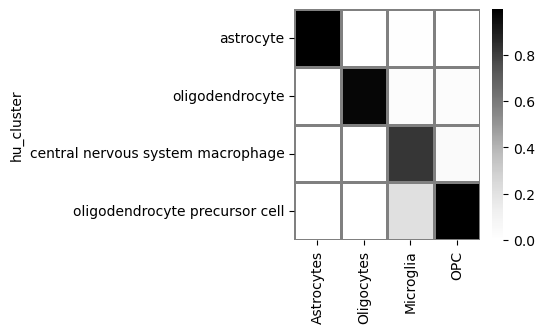

In [50]:
plt.figure(figsize = (3,3))
sns_plot = sns.heatmap(plot_cmpMatrix_mk_vs_hu_lovain_0_1, cmap='Greys', cbar=True, xticklabels=1,yticklabels=1, linewidth = 1, linecolor = 'gray')

### Figure plotting and data saving

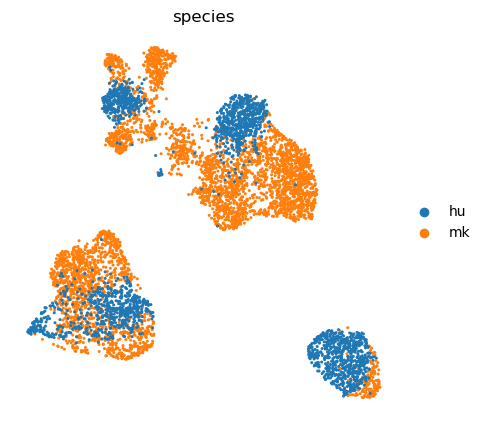

In [74]:
sc.pl.umap(adata, color=['species'], frameon=False, save='integration_Siletti_vs_mkIns_glia_speciesUMAP.pdf')

In [66]:
adata.uns['cell_type_colors'] = ['#1f77b4','#d62728','#ff7f0e','#2ca02c',]

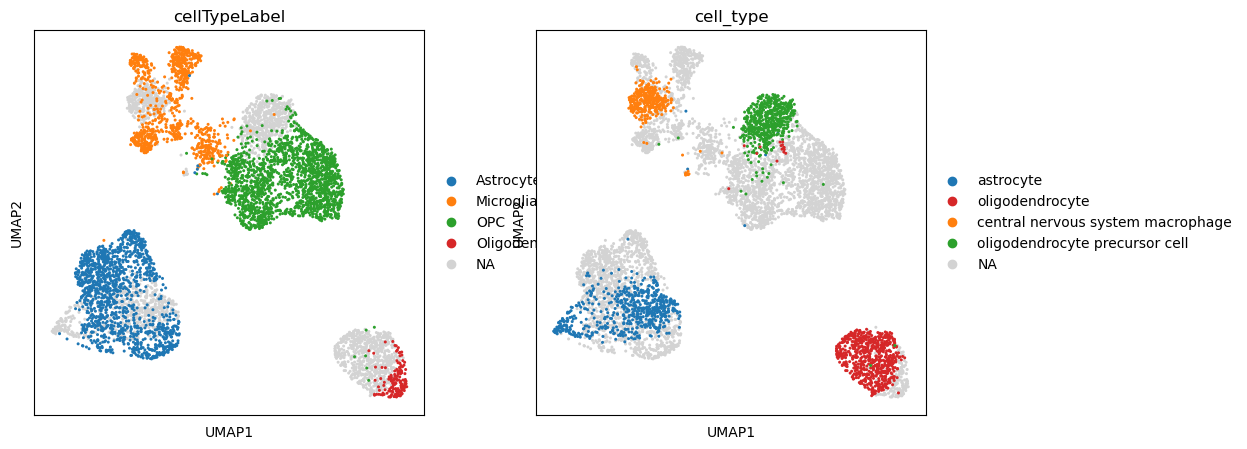

In [67]:
sc.pl.umap(adata, color=['cellTypeLabel','cell_type'])

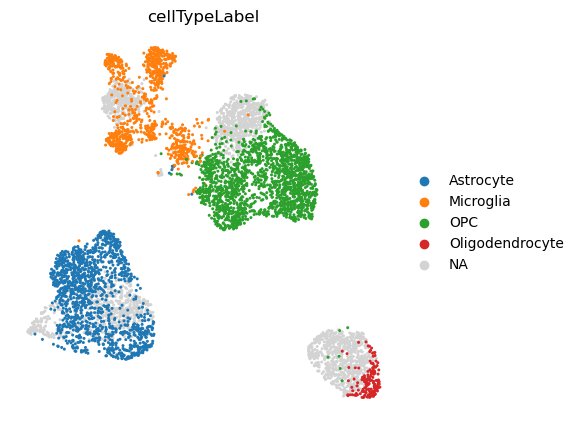

In [70]:
sc.pl.umap(adata, color=['cellTypeLabel'], frameon=False, save='integration_Siletti_vs_mkIns_glia_MKumap.pdf')

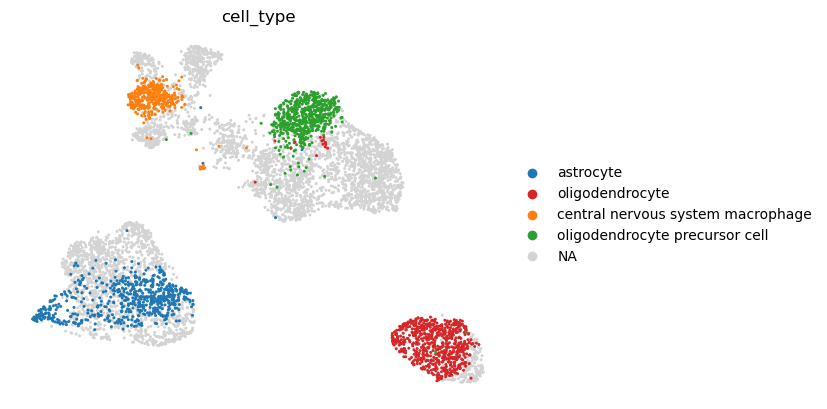

In [5]:
sc.pl.umap(adata, color=['cell_type'], frameon=False, save='integration_Siletti_vs_mkIns_glia_HumanUMAP.pdf')

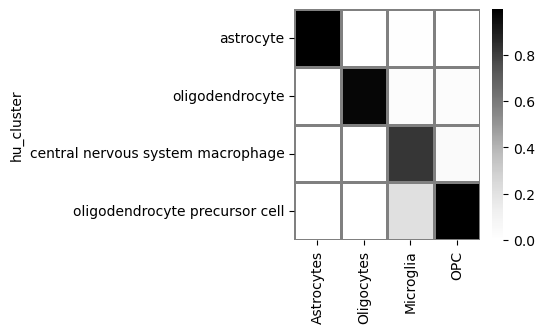

In [73]:
plt.figure(figsize = (3,3))
sns_plot = sns.heatmap(plot_cmpMatrix_mk_vs_hu_lovain_0_1, cmap='Greys', cbar=True, xticklabels=1,yticklabels=1, linewidth = 1, linecolor = 'gray')
savefig('./figs/GliaCmp_Siletti_vs_Ins.pdf',dpi=300, format='pdf')

In [76]:
ad_merged_mk_hu_integrated.write('./data_tem/ad_merged_mk_hu_integrated_allGlia_final.h5ad')
plot_cmpMatrix_mk_vs_hu_lovain_0_1.to_csv('./plot_cmpMatrix_hu_vs_mk_lovain_0_1_integrateSiletti_glia.csv')